In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!pip install -q kagglehub

In [3]:
import kagglehub

path = kagglehub.dataset_download("gti-upm/leapgestrecog")

print("Dataset path:")
print(path)

100%|██████████| 2.13G/2.13G [02:06<00:00, 18.0MB/s]

Extracting files...


Dataset path:
/root/.cache/kagglehub/datasets/gti-upm/leapgestrecog/versions/1


In [4]:
import os

print(os.listdir(path))

['leapgestrecog', 'leapGestRecog']


In [5]:
dataset_path = os.path.join(path, "leapGestRecog")

print(os.listdir(dataset_path))

['03', '06', '09', '02', '08', '01', '04', '07', '05', '00']


In [6]:
import os
import glob
import pandas as pd

data = []

for subject in sorted(os.listdir(dataset_path)):
    subject_path = os.path.join(dataset_path, subject)

    if not os.path.isdir(subject_path):
        continue

    for gesture in sorted(os.listdir(subject_path)):
        gesture_path = os.path.join(subject_path, gesture)

        if not os.path.isdir(gesture_path):
            continue

        for image_file in glob.glob(os.path.join(gesture_path, "*.png")):
            data.append({
                "image_path": image_file,
                "gesture": gesture,
                "subject": subject
            })

df = pd.DataFrame(data)

print("Total images:", len(df))
df.head()

Total images: 20000


,image_path,gesture,subject
0,/root/.cache/kagglehub/datasets/gti-upm/leapge...,01_palm,00
1,/root/.cache/kagglehub/datasets/gti-upm/leapge...,01_palm,00
2,/root/.cache/kagglehub/datasets/gti-upm/leapge...,01_palm,00
3,/root/.cache/kagglehub/datasets/gti-upm/leapge...,01_palm,00
4,/root/.cache/kagglehub/datasets/gti-upm/leapge...,01_palm,00


In [7]:
df["label"] = df["gesture"].str.split("_", n=1).str[1]

df["label"].value_counts()

,count
label,
palm,2000
l,2000
fist,2000
fist_moved,2000
thumb,2000
index,2000
ok,2000
palm_moved,2000
c,2000


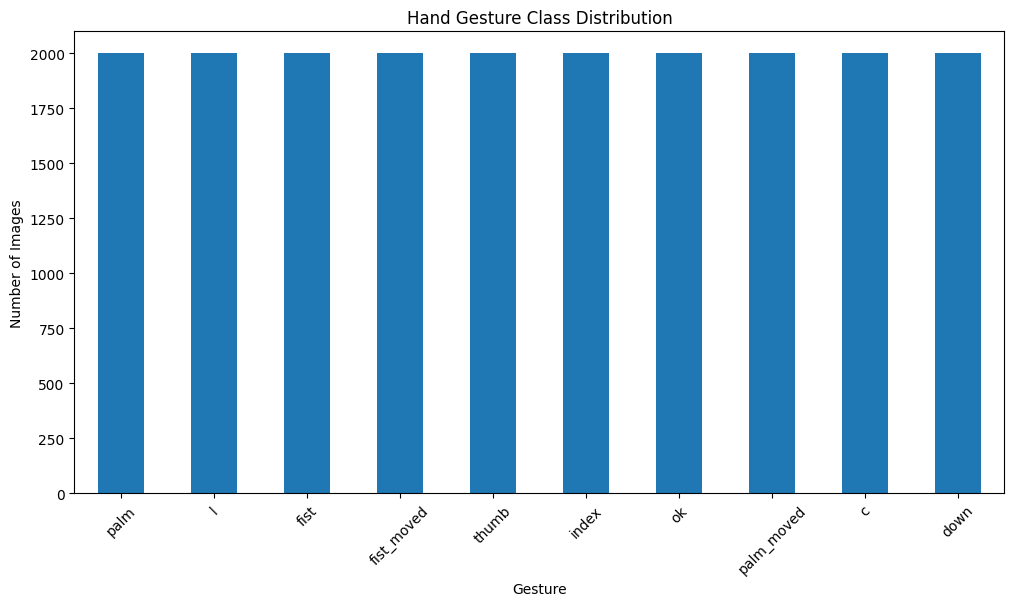

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

df["label"].value_counts().plot(kind="bar")

plt.title("Hand Gesture Class Distribution")
plt.xlabel("Gesture")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.show()

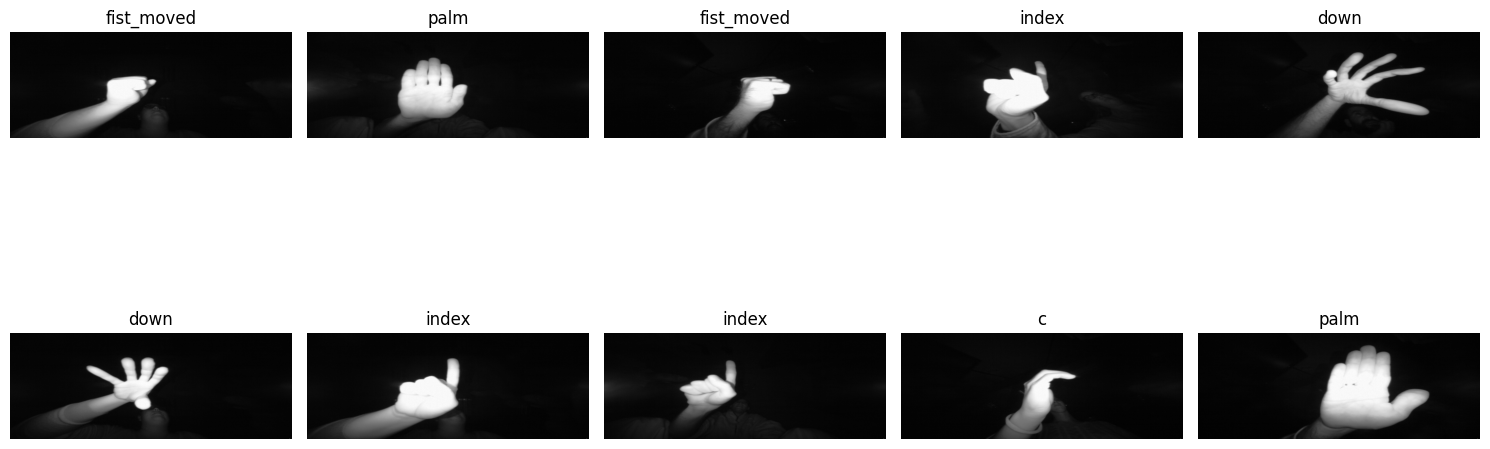

In [9]:
import matplotlib.pyplot as plt
from PIL import Image

sample_df = df.sample(10, random_state=42)

plt.figure(figsize=(15, 8))

for i, (_, row) in enumerate(sample_df.iterrows()):
    image = Image.open(row["image_path"])

    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(row["label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
train_subjects = ["00", "01", "02", "03", "04", "05", "06", "07"]
test_subjects = ["08", "09"]

train_df = df[df["subject"].isin(train_subjects)].copy()
test_df = df[df["subject"].isin(test_subjects)].copy()

print("Training images:", len(train_df))
print("Testing images:", len(test_df))

Training images: 16000
Testing images: 4000


In [11]:
class_names = sorted(train_df["label"].unique())

print(class_names)

['c', 'down', 'fist', 'fist_moved', 'index', 'l', 'ok', 'palm', 'palm_moved', 'thumb']


In [12]:
num_classes = len(class_names)

print("Number of classes:", num_classes)

Number of classes: 10


In [13]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

In [14]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    validation_split=0.2,
    subset="training",
    seed=42
)

Found 20000 files belonging to 10 classes.
Using 16000 files for training.


In [15]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_df["label_id"] = label_encoder.fit_transform(train_df["label"])
test_df["label_id"] = label_encoder.transform(test_df["label"])

class_names = list(label_encoder.classes_)

print(class_names)

['c', 'down', 'fist', 'fist_moved', 'index', 'l', 'ok', 'palm', 'palm_moved', 'thumb']


In [16]:
IMG_HEIGHT = 128
IMG_WIDTH = 128

def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=1)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [17]:
train_paths = train_df["image_path"].values
train_labels = train_df["label_id"].values

test_paths = test_df["image_path"].values
test_labels = test_df["label_id"].values

In [18]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)

In [19]:
train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [20]:
train_dataset = train_dataset.shuffle(2000).batch(BATCH_SIZE).prefetch(
    tf.data.AUTOTUNE
)

test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(
    tf.data.AUTOTUNE
)

In [21]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Input(shape=(128, 128, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,354 (12.61 MB)

 Trainable params: 3,305,354 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=test_dataset
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 57ms/step - accuracy: 0.9124 - loss: 0.3196 - val_accuracy: 0.6460 - val_loss: 3.1861
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 56ms/step - accuracy: 0.9911 - loss: 0.0297 - val_accuracy: 0.7318 - val_loss: 3.2914
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 72ms/step - accuracy: 0.9943 - loss: 0.0166 - val_accuracy: 0.7383 - val_loss: 3.3829
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 33s 58ms/step - accuracy: 0.9944 - loss: 0.0170 - val_accuracy: 0.7195 - val_loss: 2.6792
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 70ms/step - accuracy: 0.9957 - loss: 0.0155 - val_accuracy: 0.6955 - val_loss: 2.9094
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 74ms/step - accuracy: 0.9961 - loss: 0.0124 - val_accuracy: 0.7330 - val_loss: 3.3780
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 34s 61ms/step - accuracy: 0.9976 - loss: 0.0061 - val_accuracy: 0.7433 - val_loss: 3.6945
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 34s 62ms/step - accuracy: 0.9975 - loss: 0.0086 - 

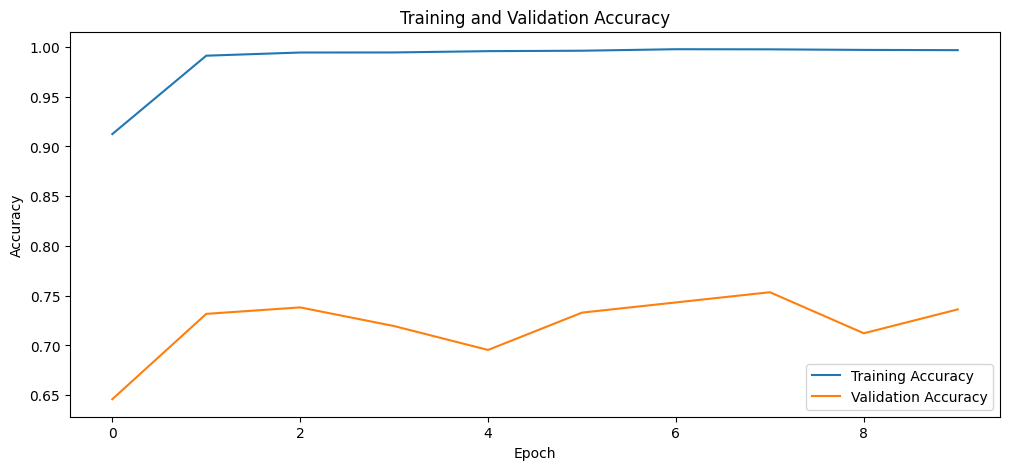

In [24]:
plt.figure(figsize=(12, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("training_history.png", dpi=300, bbox_inches="tight")

plt.show()

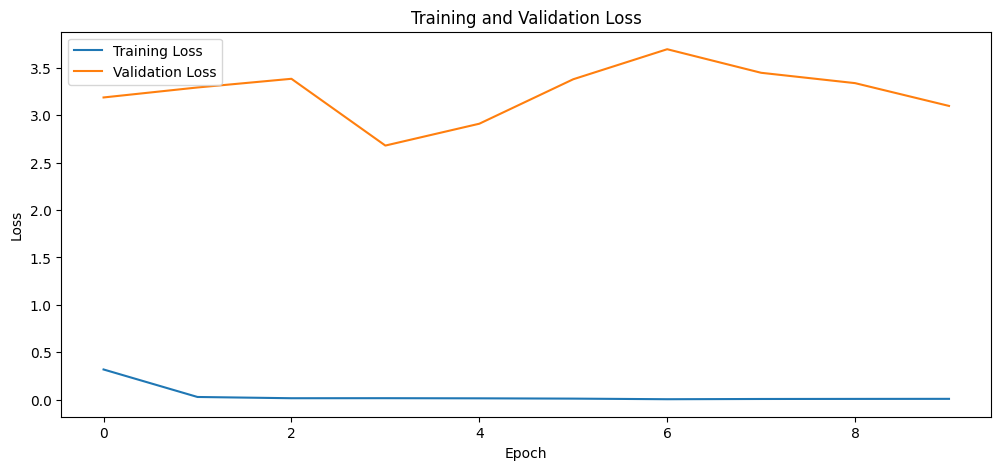

In [25]:
plt.figure(figsize=(12, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [26]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.7362 - loss: 3.0969
Test Loss: 3.0968782901763916
Test Accuracy: 0.7362499833106995


In [27]:
y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [28]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

           c       0.94      1.00      0.97       400
        down       0.83      1.00      0.91       400
        fist       0.73      0.12      0.21       400
  fist_moved       0.47      0.51      0.49       400
       index       0.97      0.87      0.91       400
           l       0.97      0.84      0.90       400
          ok       0.64      0.68      0.66       400
        palm       0.50      0.76      0.60       400
  palm_moved       0.71      1.00      0.83       400
       thumb       0.83      0.58      0.68       400

    accuracy                           0.74      4000
   macro avg       0.76      0.74      0.72      4000
weighted avg       0.76      0.74      0.72      4000



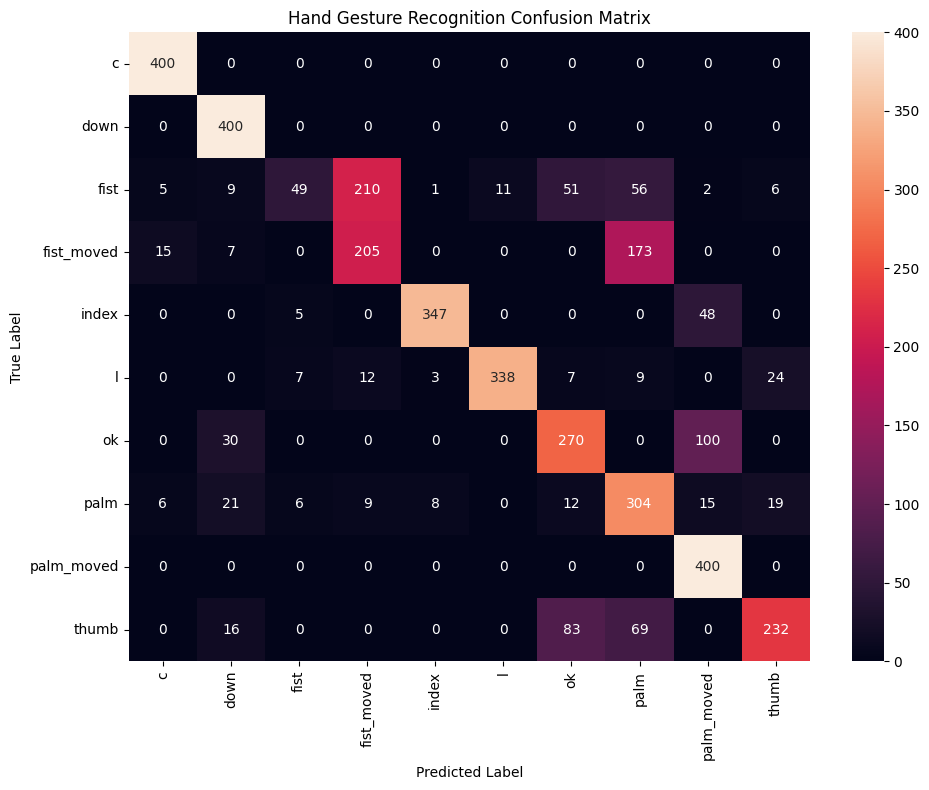

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Hand Gesture Recognition Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

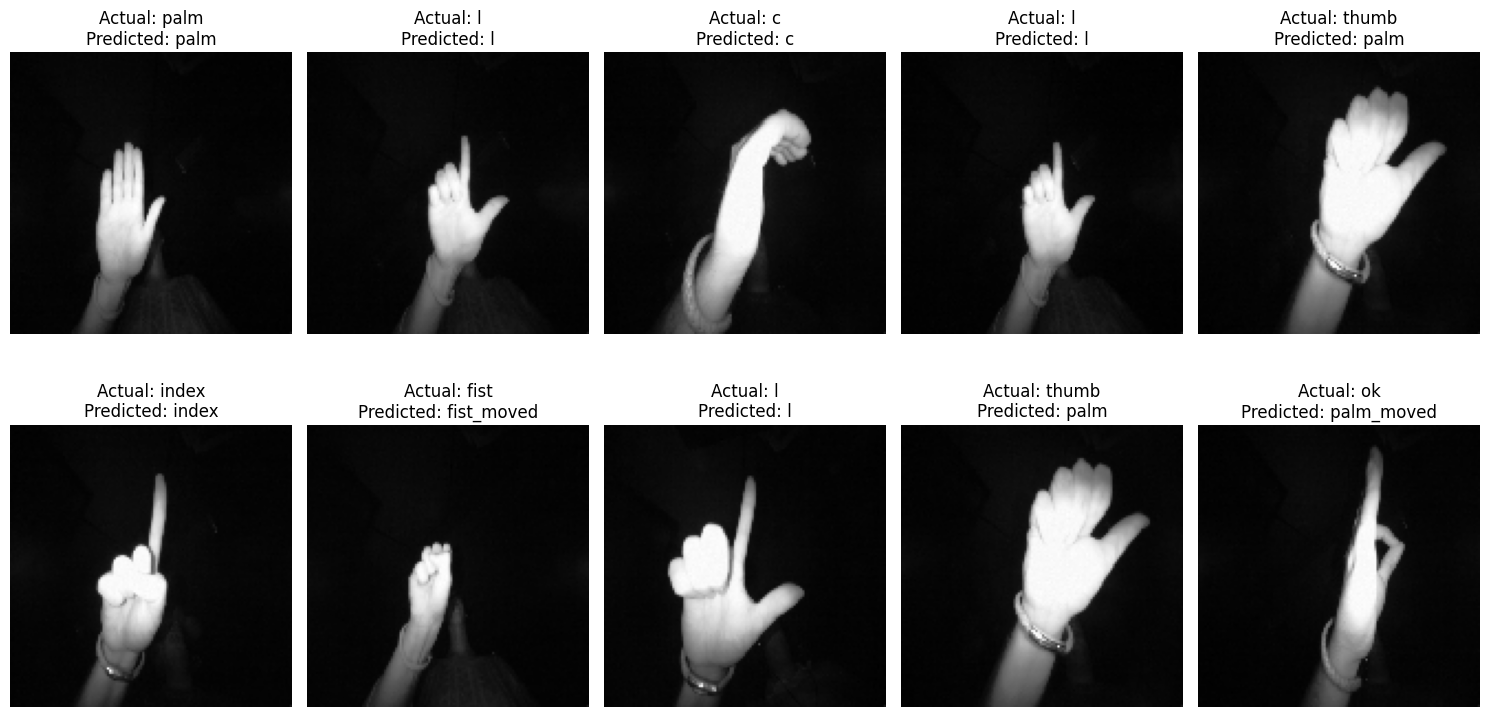

In [30]:
sample_df = test_df.sample(10, random_state=10)

plt.figure(figsize=(15, 8))

for i, (_, row) in enumerate(sample_df.iterrows()):

    image = tf.keras.utils.load_img(
        row["image_path"],
        target_size=(128, 128),
        color_mode="grayscale"
    )

    image_array = tf.keras.utils.img_to_array(image) / 255.0
    image_array = np.expand_dims(image_array, axis=0)

    prediction = model.predict(image_array, verbose=0)

    predicted_id = np.argmax(prediction)
    predicted_label = class_names[predicted_id]

    actual_label = row["label"]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image_array[0].squeeze(), cmap="gray")

    plt.title(
        f"Actual: {actual_label}\nPredicted: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "sample_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
model.save("hand_gesture_model.keras")

In [32]:
import os

print(
    "Model size:",
    os.path.getsize("hand_gesture_model.keras") / (1024 * 1024),
    "MB"
)

Model size: 37.87213325500488 MB


In [33]:
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Class names saved.")

Class names saved.


In [34]:
loaded_model = tf.keras.models.load_model(
    "hand_gesture_model.keras"
)

print("Model loaded successfully!")

Model loaded successfully!


In [35]:
import numpy as np
from PIL import Image

image_path = test_df.iloc[0]["image_path"]

image = Image.open(image_path).convert("L")
image = image.resize((128, 128))

image_array = np.array(image) / 255.0
image_array = np.expand_dims(image_array, axis=-1)
image_array = np.expand_dims(image_array, axis=0)

prediction = loaded_model.predict(image_array, verbose=0)

predicted_index = np.argmax(prediction)
predicted_label = class_names[predicted_index]

confidence = np.max(prediction)

print("Predicted Gesture:", predicted_label)
print("Confidence:", confidence)

Predicted Gesture: palm
Confidence: 0.99999976


In [36]:
print(f"Predicted Gesture: {predicted_label}")
print(f"Confidence: {confidence * 100:.2f}%")

Predicted Gesture: palm
Confidence: 100.00%


In [37]:
import os

os.makedirs("demo_images", exist_ok=True)

In [38]:
for i, (_, row) in enumerate(sample_df.iterrows()):

    image = Image.open(row["image_path"]).convert("L")
    image = image.resize((128, 128))

    image_array = np.array(image) / 255.0
    input_image = np.expand_dims(image_array, axis=(0, -1))

    prediction = loaded_model.predict(
        input_image,
        verbose=0
    )

    predicted_id = np.argmax(prediction)
    predicted_label = class_names[predicted_id]

    plt.figure(figsize=(4, 4))

    plt.imshow(image_array, cmap="gray")
    plt.title(
        f"Actual: {row['label']}\n"
        f"Predicted: {predicted_label}"
    )
    plt.axis("off")

    plt.savefig(
        f"demo_images/prediction_{i+1}.png",
        bbox_inches="tight"
    )

    plt.close()